Benchmark Price (Sobol with 16777216 samples): 9.505067480965 (Time: 4.53 seconds)
Running for 2 samples...
  Standard MC - Error: 0.414869, Time: 0.00 seconds
  Numba MC    - Error: 3.135874, Time: 5.16 seconds
  Sobol MC    - Error: 6.271813, Time: 0.00 seconds
Running for 4 samples...
  Standard MC - Error: 2.768155, Time: 0.00 seconds
  Numba MC    - Error: 0.714312, Time: 0.00 seconds
  Sobol MC    - Error: 7.025280, Time: 0.00 seconds
Running for 8 samples...
  Standard MC - Error: 0.520775, Time: 0.00 seconds
  Numba MC    - Error: 0.572635, Time: 0.00 seconds
  Sobol MC    - Error: 3.544451, Time: 0.00 seconds
Running for 16 samples...
  Standard MC - Error: 0.926448, Time: 0.00 seconds
  Numba MC    - Error: 1.103323, Time: 0.00 seconds
  Sobol MC    - Error: 2.413044, Time: 0.00 seconds
Running for 32 samples...
  Standard MC - Error: 0.382156, Time: 0.00 seconds
  Numba MC    - Error: 0.229907, Time: 0.00 seconds
  Sobol MC    - Error: 1.091226, Time: 0.00 seconds
Running fo

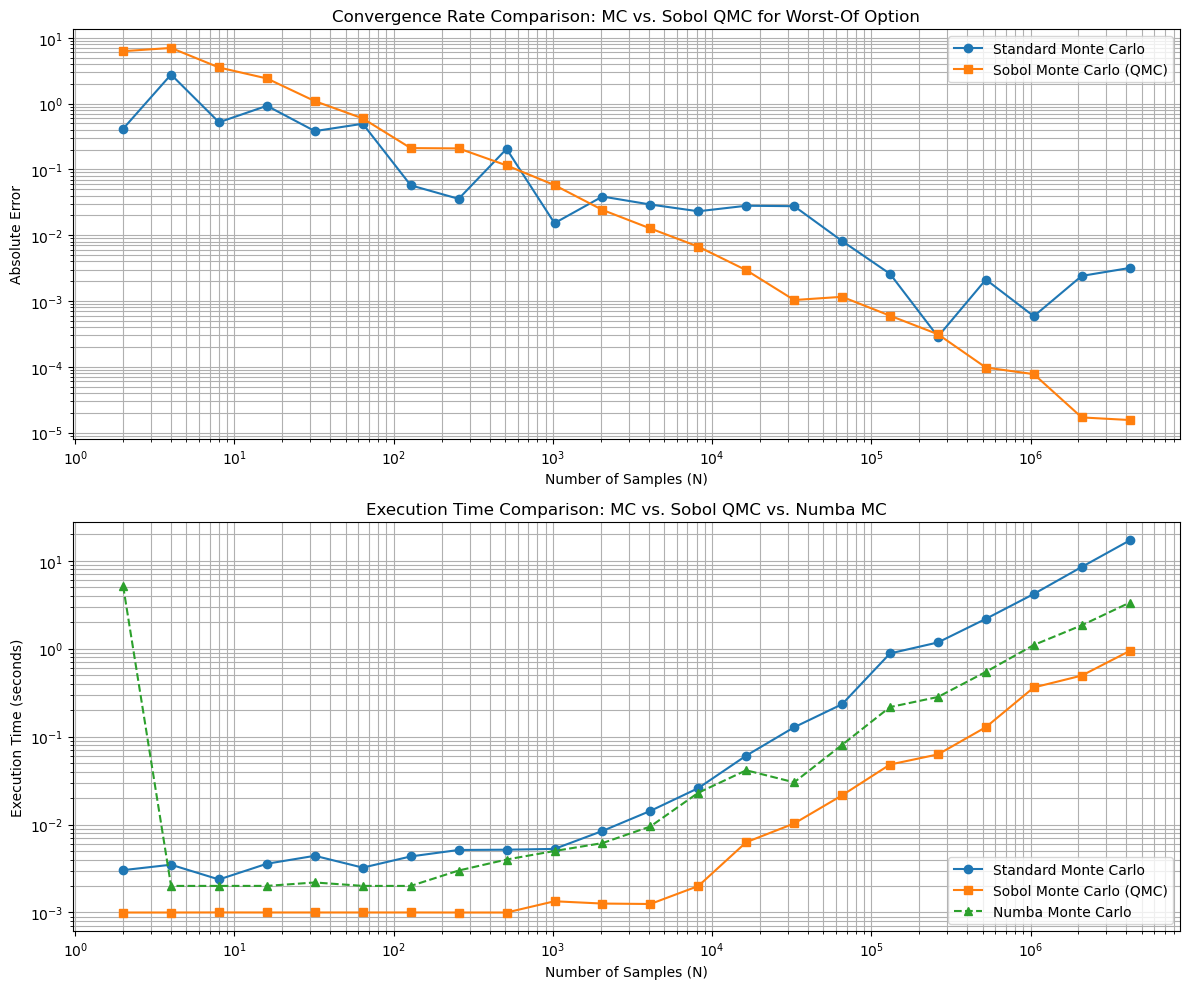


Estimated convergence rate for MC (slope in log-log plot): -0.51
Estimated convergence rate for Sobol QMC (slope in log-log plot): -0.93


In [1]:
import time
import numpy as np
from scipy.stats import norm, qmc
import matplotlib.pyplot as plt
from numba import jit

def worst_of_two_equity_option_mc(S1_0, S2_0, K, r, sigma1, sigma2, rho, T, n_samples):
    """
    Calculates the price of a European worst-of-two equity option using standard
    Monte Carlo simulation.
    """
    Z1 = np.random.standard_normal(n_samples)
    Z2 = np.random.standard_normal(n_samples)

    # Generate correlated standard normal random numbers using Cholesky
    correlation_matrix = np.array([[1, rho],
                                    [rho, 1]])
    L = np.linalg.cholesky(correlation_matrix)
    correlated_normal_points = np.dot(np.column_stack((Z1, Z2)), L.T)
    Z1_corr = correlated_normal_points[:, 0]
    Z2_corr = correlated_normal_points[:, 1]

    S1_T = S1_0 * np.exp((r - 0.5 * sigma1**2) * T + sigma1 * np.sqrt(T) * Z1_corr)
    S2_T = S2_0 * np.exp((r - 0.5 * sigma2**2) * T + sigma2 * np.sqrt(T) * Z2_corr)

    payoffs = np.maximum(0, np.minimum(S1_T, S2_T) - K)
    option_price = np.exp(-r * T) * np.mean(payoffs)
    return option_price
@jit(nopython=True, parallel=True, fastmath=True)
def worst_of_two_equity_option_mc_numba(S1_0, S2_0, K, r, sigma1, sigma2, rho, T, n_samples):
    """
    Calculates the price of a European worst-of-two equity option using standard
    Monte Carlo simulation (Numba optimized).
    """
    Z1 = np.random.standard_normal(n_samples)
    Z2 = np.random.standard_normal(n_samples)

    # Generate correlated standard normal random numbers using Cholesky
    correlation_matrix = np.array([[1.0, rho],
                                    [rho, 1.0]])
    L = np.linalg.cholesky(correlation_matrix)
    correlated_normal_points = np.empty((n_samples, 2))
    for i in range(n_samples):
        correlated_normal_points[i, 0] = L[0, 0] * Z1[i] + L[0, 1] * Z2[i]
        correlated_normal_points[i, 1] = L[1, 0] * Z1[i] + L[1, 1] * Z2[i]

    Z1_corr = correlated_normal_points[:, 0]
    Z2_corr = correlated_normal_points[:, 1]

    S1_T = S1_0 * np.exp((r - 0.5 * sigma1**2) * T + sigma1 * np.sqrt(T) * Z1_corr)
    S2_T = S2_0 * np.exp((r - 0.5 * sigma2**2) * T + sigma2 * np.sqrt(T) * Z2_corr)

    payoffs = np.maximum(0.0, np.minimum(S1_T, S2_T) - K)
    option_price = np.exp(-r * T) * np.mean(payoffs)
    return option_price

def worst_of_two_equity_option_sobol(S1_0, S2_0, K, r, sigma1, sigma2, rho, T, n_samples):
    """
    Calculates the price of a European worst-of-two equity option using Sobol
    multivariate Monte Carlo simulation.
    """
    sampler = qmc.Sobol(d=2, scramble=False, seed=42)
    sobol_points = sampler.random(n=n_samples)

    # Add a small value to avoid 0
    epsilon = 1e-9
    adjusted_sobol_points = np.clip(sobol_points + epsilon, epsilon, 1 - epsilon)

    normal_points = norm.ppf(adjusted_sobol_points)

    correlation_matrix = np.array([[1, rho],
                                    [rho, 1]])
    try:
        L = np.linalg.cholesky(correlation_matrix)
    except np.linalg.LinAlgError:
        print("Error: Correlation matrix is not positive semi-definite.")
        return np.nan

    correlated_normal_points = np.dot(normal_points, L.T)
    Z1 = correlated_normal_points[:, 0]
    Z2 = correlated_normal_points[:, 1]

    S1_T = S1_0 * np.exp((r - 0.5 * sigma1**2) * T + sigma1 * np.sqrt(T) * Z1)
    S2_T = S2_0 * np.exp((r - 0.5 * sigma2**2) * T + sigma2 * np.sqrt(T) * Z2)

    if np.isnan(S1_T).any() or np.isnan(S2_T).any():
        print("Warning: NaN detected in simulated asset prices.")

    payoffs = np.maximum(0, np.minimum(S1_T, S2_T) - K)

    if np.isnan(payoffs).any():
        print("Warning: NaN detected in payoffs.")

    option_price = np.exp(-r * T) * np.mean(payoffs)
    return option_price

if __name__ == '__main__':
    # Option parameters
    S1_0 = 100
    S2_0 = 95
    K = 90
    r = 0.05
    sigma1 = 0.2
    sigma2 = 0.25
    rho = 0.6
    T = 1.0

    # Sample sizes to test
    n_samples_list = [2**i for i in range(1, 23)] # Reduced the range for quicker execution

    # Number of repetitions for standard Monte Carlo to get average
    n_repetitions = 30

    mc_errors = []
    sobol_errors = []
    mc_times = []
    sobol_times = []
    numba_mc_times = []

    # Calculate benchmark price using a large number of Sobol samples
    n_samples_benchmark = 2**24
    start_time = time.time()
    benchmark_price = worst_of_two_equity_option_sobol(S1_0, S2_0, K, r, sigma1, sigma2, rho, T, n_samples_benchmark)
    end_time = time.time()
    print(f"Benchmark Price (Sobol with {n_samples_benchmark} samples): {benchmark_price:.12f} (Time: {end_time - start_time:.2f} seconds)")

    for n_samples in n_samples_list:
        print(f"Running for {n_samples} samples...")

        # Standard Monte Carlo
        start_time_mc = time.time()
        mc_prices = [worst_of_two_equity_option_mc(S1_0, S2_0, K, r, sigma1, sigma2, rho, T, n_samples)
                     for _ in range(n_repetitions)]
        end_time_mc = time.time()
        mc_time = end_time_mc - start_time_mc
        mc_times.append(mc_time)
        mc_error = np.abs(np.mean(mc_prices) - benchmark_price)
        mc_errors.append(mc_error)
        print(f"  Standard MC - Error: {mc_error:.6f}, Time: {mc_time:.2f} seconds")

        # Numba optimized Monte Carlo
        start_time_numba_mc = time.time()
        numba_mc_prices = [worst_of_two_equity_option_mc_numba(S1_0, S2_0, K, r, sigma1, sigma2, rho, T, n_samples)
                             for _ in range(n_repetitions)]
        end_time_numba_mc = time.time()
        numba_mc_time = end_time_numba_mc - start_time_numba_mc
        numba_mc_times.append(numba_mc_time)
        numba_mc_error = np.abs(np.mean(numba_mc_prices) - benchmark_price)
        print(f"  Numba MC    - Error: {numba_mc_error:.6f}, Time: {numba_mc_time:.2f} seconds")

        # Sobol Monte Carlo
        start_time_sobol = time.time()
        sobol_price = worst_of_two_equity_option_sobol(S1_0, S2_0, K, r, sigma1, sigma2, rho, T, n_samples)
        end_time_sobol = time.time()
        sobol_time = end_time_sobol - start_time_sobol
        sobol_times.append(sobol_time)
        sobol_error = np.abs(sobol_price - benchmark_price)
        sobol_errors.append(sobol_error)
        print(f"  Sobol MC    - Error: {sobol_error:.6f}, Time: {sobol_time:.2f} seconds")

    # Plotting the convergence rates and times
    plt.figure(figsize=(12, 10))

    # First subplot for convergence rates
    plt.subplot(2, 1, 1)
    plt.loglog(n_samples_list, mc_errors, label='Standard Monte Carlo', marker='o', linestyle='-')
    plt.loglog(n_samples_list, sobol_errors, label='Sobol Monte Carlo (QMC)', marker='s', linestyle='-')
    plt.xlabel('Number of Samples (N)')
    plt.ylabel('Absolute Error')
    plt.title('Convergence Rate Comparison: MC vs. Sobol QMC for Worst-Of Option')
    plt.legend()
    plt.grid(True, which="both", ls="-")

    # Second subplot for execution times
    plt.subplot(2, 1, 2)
    plt.loglog(n_samples_list, mc_times, label='Standard Monte Carlo', marker='o', linestyle='-')
    plt.loglog(n_samples_list, sobol_times, label='Sobol Monte Carlo (QMC)', marker='s', linestyle='-')
    plt.loglog(n_samples_list, numba_mc_times, label='Numba Monte Carlo', marker='^', linestyle='--')
    plt.xlabel('Number of Samples (N)')
    plt.ylabel('Execution Time (seconds)')
    plt.title('Execution Time Comparison: MC vs. Sobol QMC vs. Numba MC')
    plt.legend()
    plt.grid(True, which="both", ls="-")

    plt.tight_layout()
    plt.show()

    # Optional: Fit lines to estimate the convergence rates
    # For MC, we expect a slope of around -0.5 in log-log scale
    # For QMC, we expect a slope closer to -1

    # Fit a line to the MC error
    mc_log_n = np.log(n_samples_list)
    mc_log_errors = np.log(mc_errors)
    mc_slope, mc_intercept = np.polyfit(mc_log_n, mc_log_errors, 1)
    print(f"\nEstimated convergence rate for MC (slope in log-log plot): {mc_slope:.2f}")

    # Fit a line to the Sobol error (ignoring initial fluctuations)
    sobol_log_n = np.log(n_samples_list)
    sobol_log_errors = np.log(sobol_errors)
    sobol_slope, sobol_intercept = np.polyfit(sobol_log_n, sobol_log_errors, 1)
    print(f"Estimated convergence rate for Sobol QMC (slope in log-log plot): {sobol_slope:.2f}")